In [19]:
from diffrax import ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.svgd import svgd
from utilities.helpers import effective_sample_size,autocorr_new,gr_statistic

In [20]:
beta = jnp.log(0.4)
eta = jnp.log(1/7)
gamma = jnp.log(1/14)
q= jnp.log(0.1)
mu = jnp.log(0.01)
I0 = jnp.log(0.01)
rho = jnp.log(0.4)

par_true = jnp.array([beta,eta,gamma,q,mu])

t_vec = jnp.linspace(0,50,50)

def SEIR(t,y,args):
  beta,eta,gamma,q,mu = args

  beta = jnp.exp(beta)
  eta = jnp.exp(eta)
  gamma = jnp.exp(gamma)
  q = jnp.exp(q)
  mu = jnp.exp(mu)

  S,E,I,R = y
  N = S+E+I+R

  dS = - beta * ((E + q * I)/N) * S
  dE = beta * ((E + q * I)/N) * S - eta*E - gamma * E
  dI = eta * E - gamma * I - mu * I
  dR = gamma * E + gamma * I


  return jnp.array([dS,dE,dI,dR])

In [21]:
def model(ts, y0, par):
    solution = diffrax.diffeqsolve(
        ODETerm(SEIR),
        diffrax.Dopri5(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.1,
        y0=y0,
        args=par,
        saveat=diffrax.SaveAt(ts=ts),
    )
    return solution.ys


rng_key = jax.random.PRNGKey(0)

N = 1000
y_true = model(
    t_vec,
    jnp.array([N - N * jnp.exp(I0), N * jnp.exp(I0), 0, 0]),
    (beta, eta, gamma, q, mu),
)

key = jax.random.key(0)

key, I_noise_key = jax.random.split(key)
data_newI = jax.random.poisson(I_noise_key, jnp.exp(rho) * jnp.exp(eta) * y_true[:, 1] + 0.005)

key, D_noise_key = jax.random.split(key)
data_newD = jax.random.poisson(D_noise_key, jnp.exp(mu) * y_true[:, 2] + 0.005)

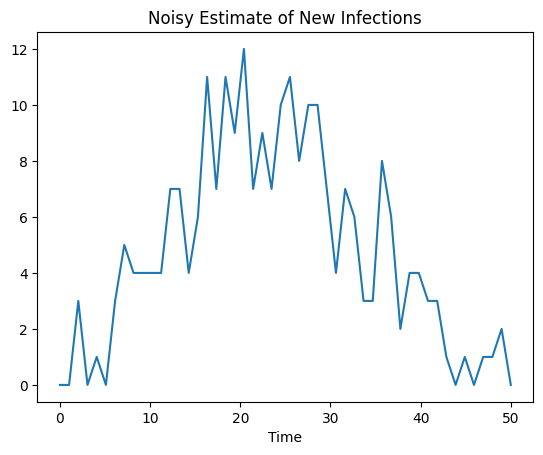

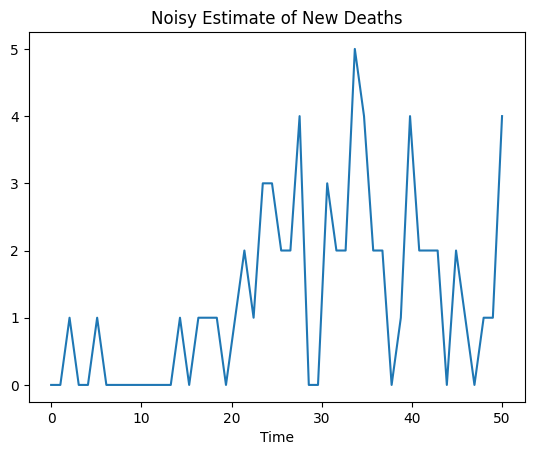

In [22]:
plt.title('Noisy Estimate of New Infections')
plt.plot(t_vec,data_newI)
plt.xlabel('Time')
plt.show()

plt.title('Noisy Estimate of New Deaths')
plt.xlabel('Time')
plt.plot(t_vec,data_newD)
plt.show()

In [23]:
def log_likelihood(par):

    N = 1000.0
    beta, eta, gamma, q, mu, I0, rho = par
    model_output = model(
        t_vec,
        jnp.array([N - N * jnp.exp(I0), N * jnp.exp(I0), 0., 0.]),
        (beta, eta, gamma, q, mu),
    )
    pdf_0 = poisson.logpmf(data_newI, jnp.exp(rho) * jnp.maximum(jnp.exp(eta) * model_output[:, 1], 1e-6))

    pdf_1 = poisson.logpmf(data_newD, jnp.maximum(jnp.exp(mu) * model_output[:, 2], 1e-6))
    return jnp.sum(pdf_0 + pdf_1)

In [24]:
@jax.jit
def joint(par):
    return log_likelihood(par)

In [25]:
D = 7
num_particles = 100
iterations = 100
key = jax.random.key(0)
init_key, key = jax.random.split(key)

theta0 = jax.random.multivariate_normal(
    init_key,
    mean=jnp.log(jnp.array([0.1, 0.1, 0.1, 0.1, 0.01, 0.1, 0.01])),
    cov=jnp.eye(D),
    shape=num_particles,
)


def RBF_Kernel(x, x_prime, bandwidth):
    sq_dist = jnp.sum((x - x_prime) ** 2)
    return jnp.exp(-bandwidth * sq_dist)


In [26]:
svgd_key, key = jax.random.split(key)
t0 = perf_counter()
svgd_samples = svgd(
joint,
RBF_Kernel,
num_particles,
iterations,
0.01,
svgd_key,
D
)
t1 = perf_counter()

print(svgd_samples)

[[nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan]
 [nan na

IndexError: list index out of range

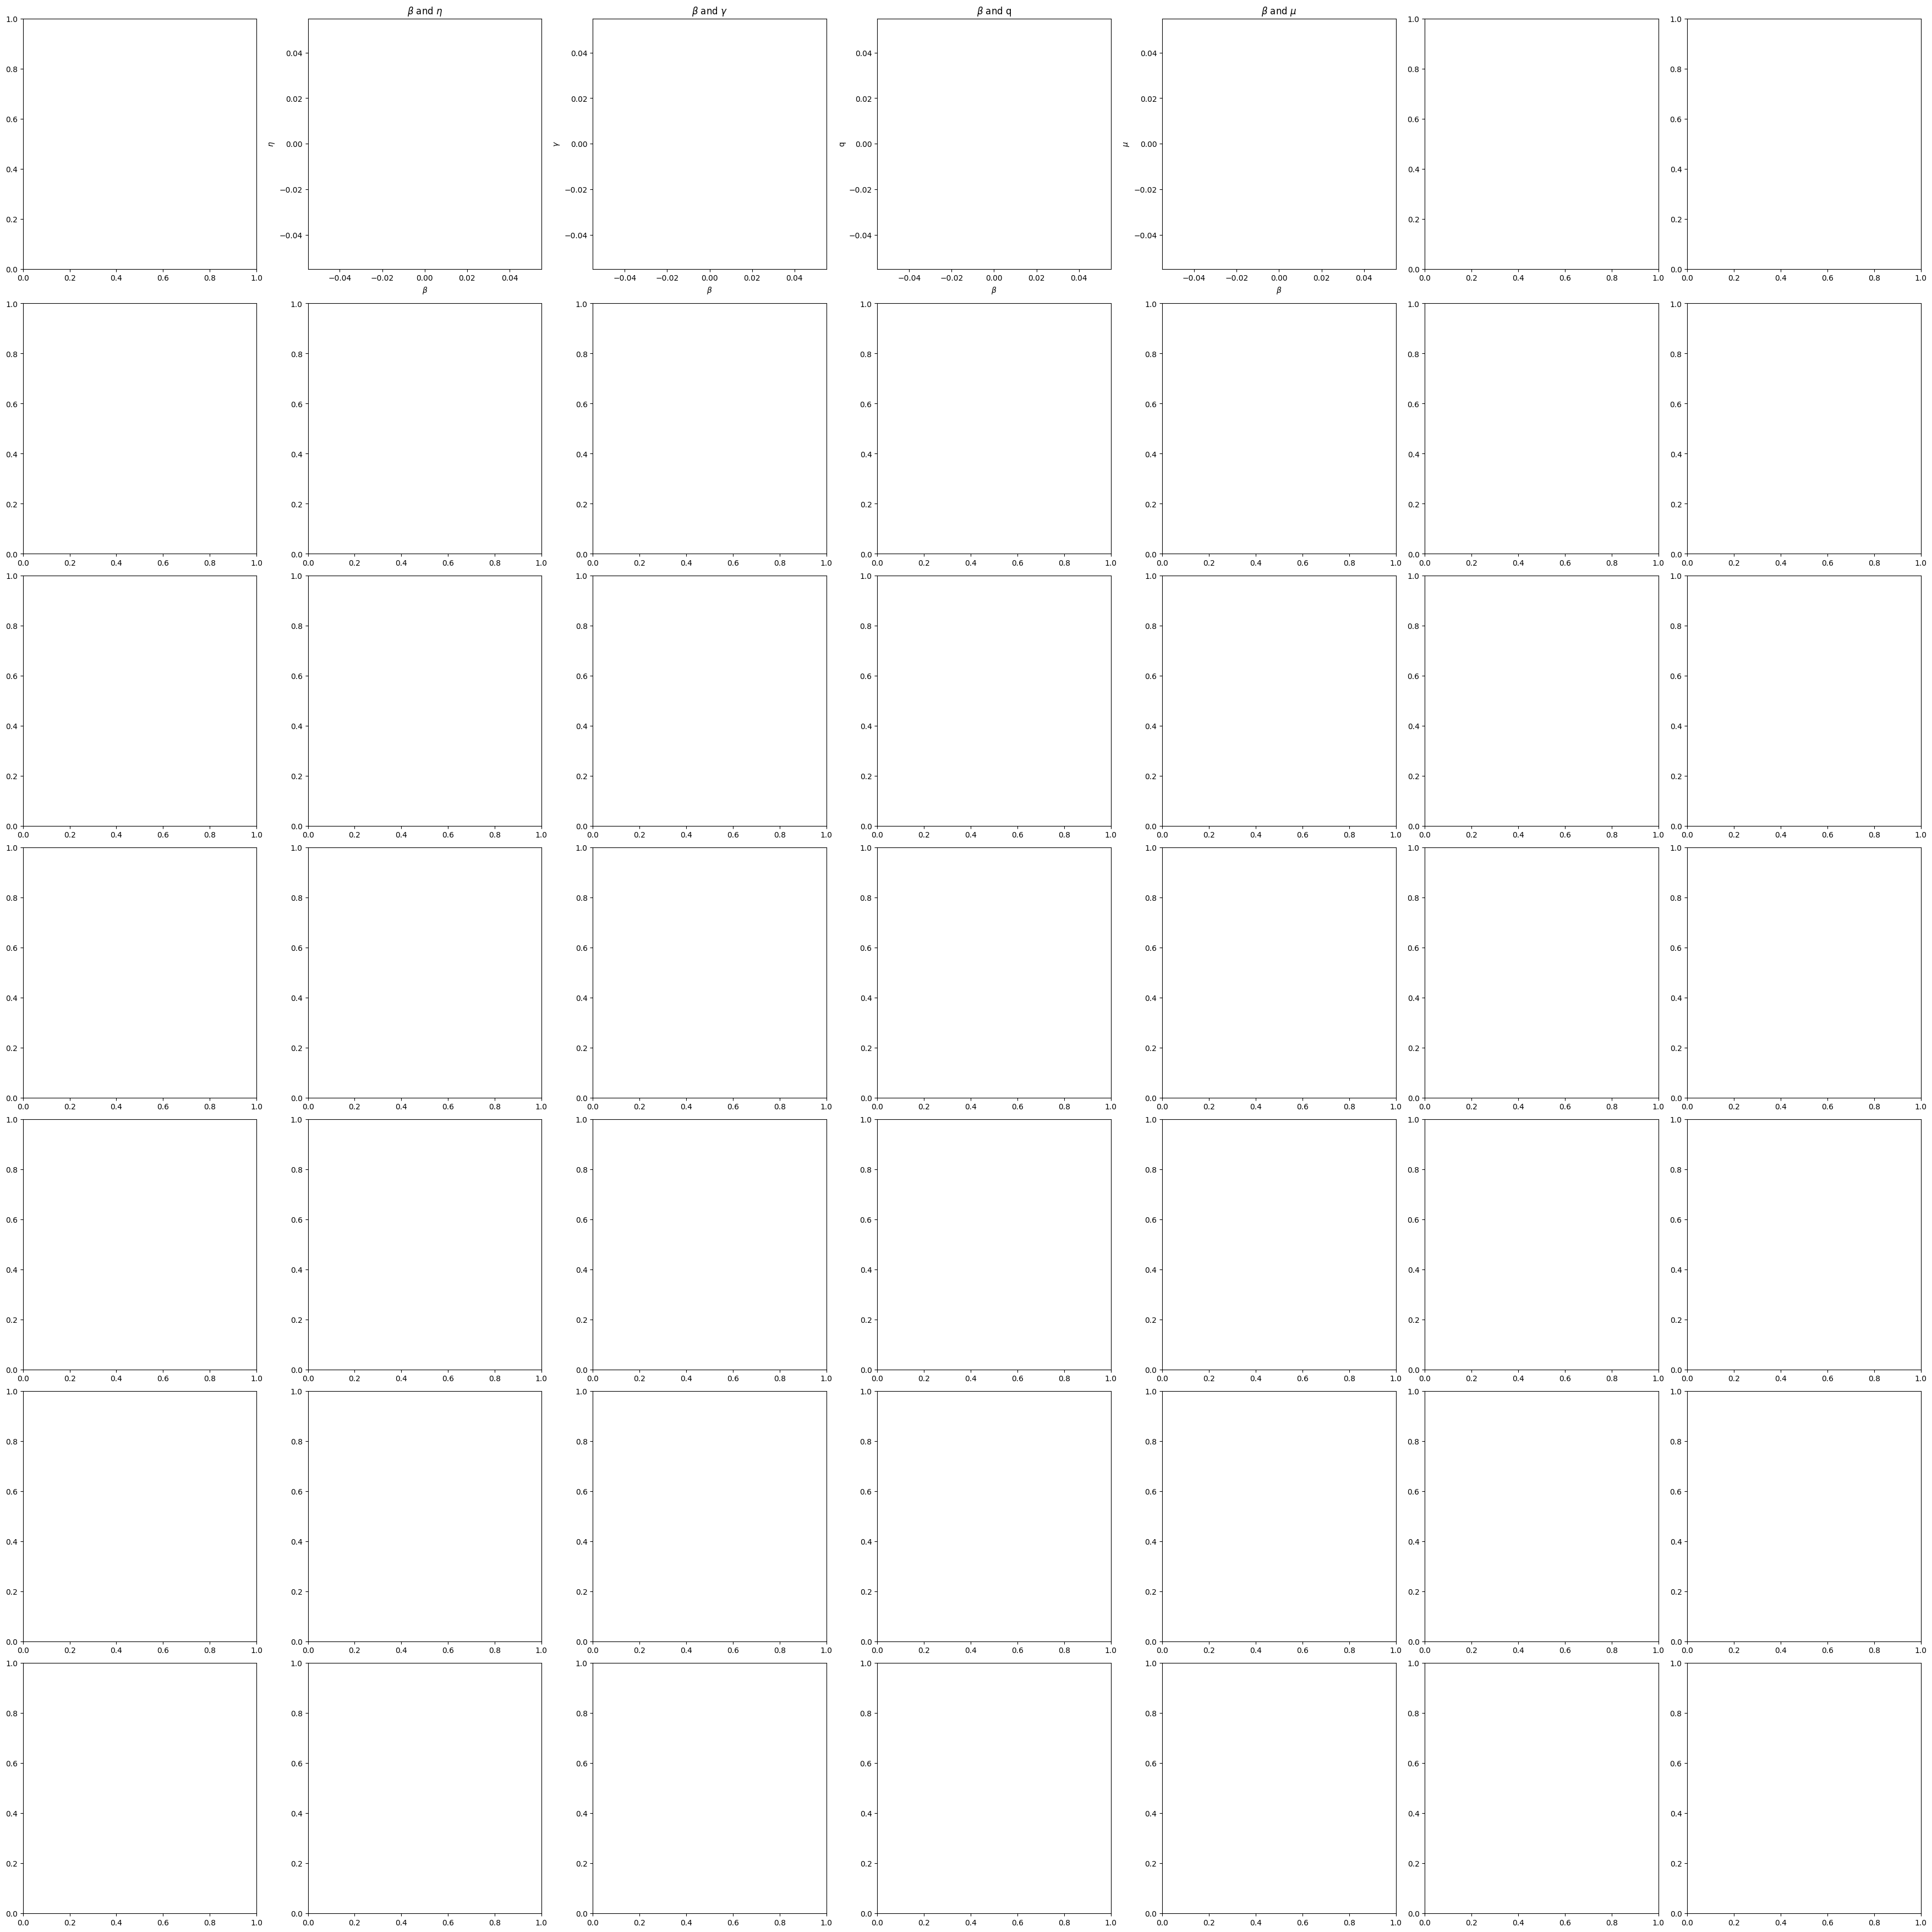

In [27]:
fig, axes = plt.subplots(D, D, figsize=(5*D, 5*D),layout="constrained")

par_names = ["$\\beta$", "$\\eta$", "$\\gamma$", "q", "$\\mu$"]


for par1_index in range(D):
    for par2_index in range(D):

        if par1_index != par2_index: 
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                svgd_samples[:, par1_index],
                svgd_samples[:, par2_index],
                s = 0.5
            )
            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

plt.show()
